## D.	Models: Fitting and Interpretation 

### Import modules

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
from sklearn.preprocessing import StandardScaler
import statsmodels.formula.api as smf
from sklearn.metrics import confusion_matrix

In [3]:
from sklearn.metrics import roc_curve
from sklearn.metrics import roc_auc_score

## Read Data


In [4]:
df = pd.read_csv( 'df_EDA' )

In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 28356 entries, 0 to 28355
Data columns (total 10 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   track_id                  28356 non-null  object 
 1   track_popularity          28356 non-null  int64  
 2   playlist_genre            28356 non-null  object 
 3   danceability              28356 non-null  float64
 4   track_album_release_date  28356 non-null  object 
 5   tempo                     28356 non-null  float64
 6   energy                    28356 non-null  float64
 7   popularity_category       28356 non-null  object 
 8   release_year              28356 non-null  int64  
 9   bin_year                  28356 non-null  object 
dtypes: float64(3), int64(2), object(5)
memory usage: 2.2+ MB


Identifying continuous variables that are not “Gaussian-like”.

In [6]:
df_features = df[['danceability', 'tempo', 'energy']].copy()

C:\Anaconda\envs\cmpinf2100\lib\site-packages\seaborn\axisgrid.py:123: UserWarning: The figure layout has changed to tight
  self._figure.tight_layout(*args, **kwargs)


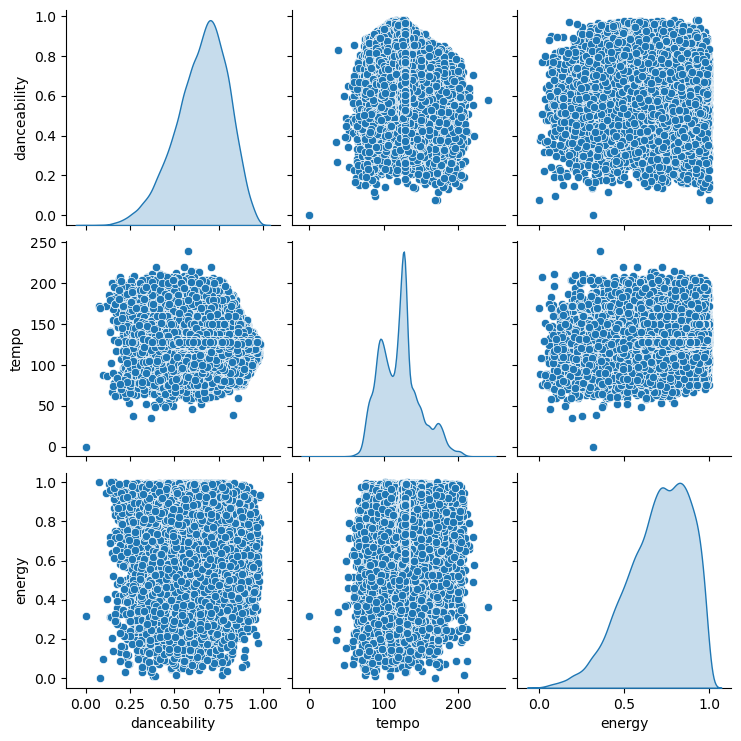

In [7]:
sns.pairplot( data = df_features, diag_kind='kde',  diag_kws={'common_norm': False})

plt.show()

`tempo` is not "Gaussian-like" applying natural log to help make the distribution more "Gaussian-like".

In [8]:
df['log_tempo'] = np.log1p(df['tempo']) #avoid log(0)

In [9]:
df[['tempo', 'log_tempo']]

,tempo,log_tempo
0,122.036,4.812477
1,99.972,4.614843
2,124.008,4.828378
3,121.956,4.811827
4,123.976,4.828122
...,...,...
28351,128.170,4.861129
28352,128.041,4.860130
28353,127.989,4.859727
28354,128.008,4.859874


In [10]:
df_features = df[['danceability', 'log_tempo', 'energy']].copy()

In [11]:
df_features

,danceability,log_tempo,energy
0,0.748,4.812477,0.916
1,0.726,4.614843,0.815
2,0.675,4.828378,0.931
3,0.718,4.811827,0.930
4,0.650,4.828122,0.833
...,...,...,...
28351,0.428,4.861129,0.922
28352,0.522,4.860130,0.786
28353,0.529,4.859727,0.821
28354,0.626,4.859874,0.888


Verify if continuous inputs are standardize.

C:\Anaconda\envs\cmpinf2100\lib\site-packages\seaborn\axisgrid.py:123: UserWarning: The figure layout has changed to tight
  self._figure.tight_layout(*args, **kwargs)


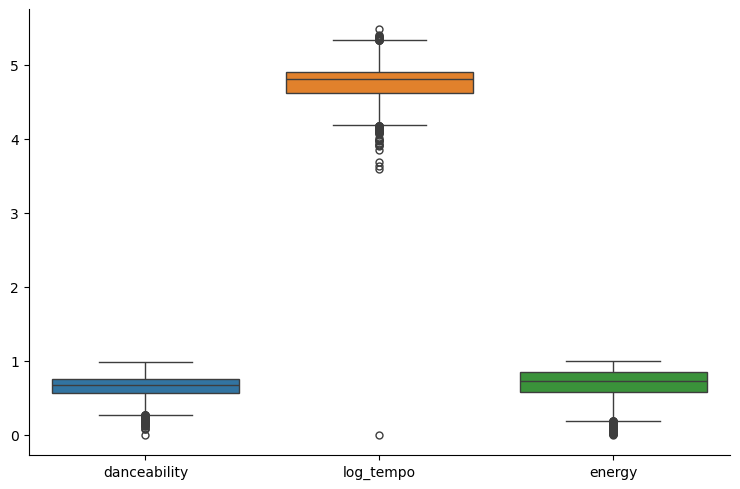

In [12]:
sns.catplot( data = df_features, kind='box', aspect=1.5)

plt.show()

Applying `StandardScale()` to standardize the continuous inputs.

In [13]:
dfx = StandardScaler().fit_transform( df_features )

C:\Anaconda\envs\cmpinf2100\lib\site-packages\seaborn\axisgrid.py:123: UserWarning: The figure layout has changed to tight
  self._figure.tight_layout(*args, **kwargs)


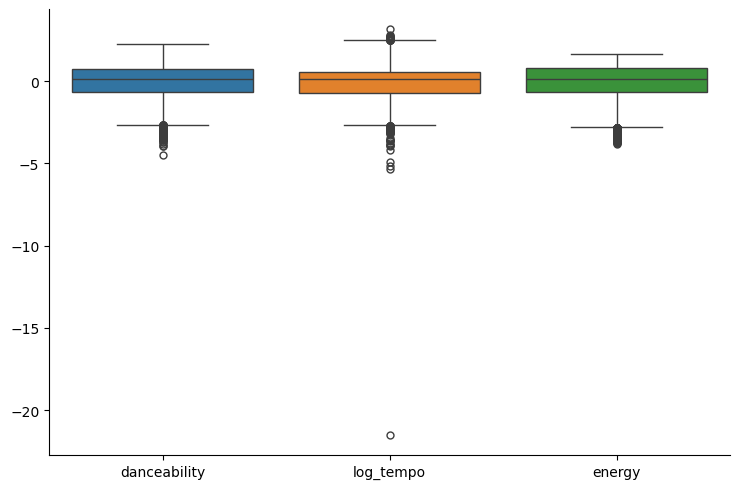

In [14]:
sns.catplot( data = pd.DataFrame( dfx, columns = df_features.columns), kind='box', aspect=1.5)

plt.show()

Converting `populatory_category` classification to binary classification name `target`.

The binary classification label is the following:

- 1 if the song is "very_popular" or "popular"

- 0 if the song is "not_popular"

In [15]:
df["target"] = df["popularity_category"].isin(["very_popular", "popular"]).astype(int)

C:\Anaconda\envs\cmpinf2100\lib\site-packages\seaborn\axisgrid.py:123: UserWarning: The figure layout has changed to tight
  self._figure.tight_layout(*args, **kwargs)


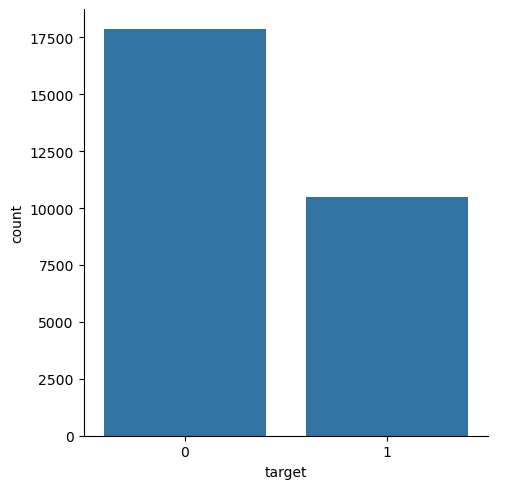

In [16]:
sns.catplot( data = df, x='target', kind='count')

plt.show()

Not popular has more values than popular.

Create a list which contains the formulas that are going to be used to fit the models.

In [17]:
formula_list = ['target ~ 1',
                'target ~ playlist_genre',
                'target ~ danceability + log_tempo + energy',
                'target ~ danceability + log_tempo + energy + playlist_genre',
                'target ~ danceability + log_tempo + energy + danceability:log_tempo + danceability:energy + log_tempo:energy',
                'target ~ danceability + log_tempo + energy + playlist_genre + danceability:playlist_genre + log_tempo:playlist_genre + energy:playlist_genre',
                'target ~ playlist_genre + bin_year + playlist_genre:bin_year',
                'target ~ danceability + log_tempo + energy + I(danceability**2) + I(log_tempo**2) + I(energy**2)']
                

Create a for-loop that iterates through all the formulas in `formula_list`, fit them in model, in order to make predictions, to visualize them in a confusion matrix.

Optimization terminated successfully.
         Current function value: 0.659223
         Iterations 4


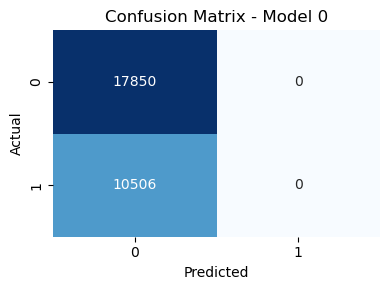

Optimization terminated successfully.
         Current function value: 0.635450
         Iterations 5


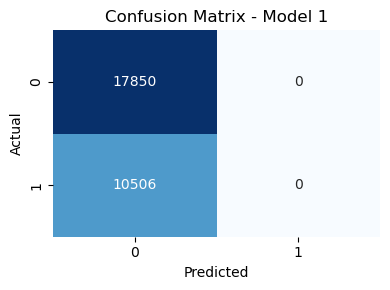

Optimization terminated successfully.
         Current function value: 0.655644
         Iterations 4


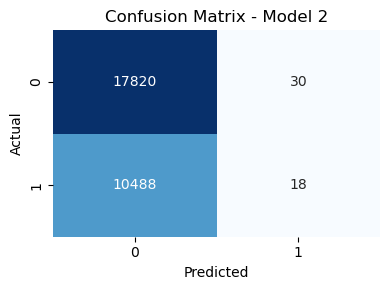

Optimization terminated successfully.
         Current function value: 0.632931
         Iterations 5


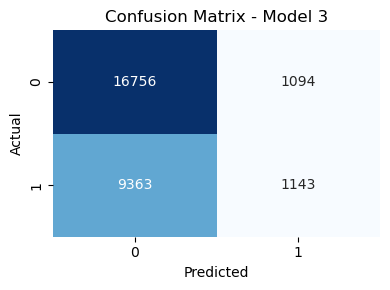

Optimization terminated successfully.
         Current function value: 0.655419
         Iterations 5


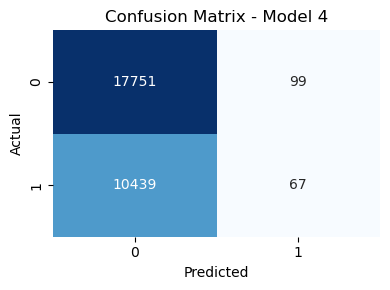

Optimization terminated successfully.
         Current function value: 0.630261
         Iterations 6


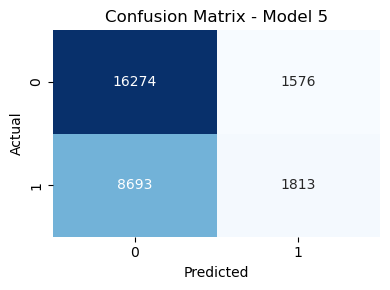

Optimization terminated successfully.
         Current function value: 0.628309
         Iterations 6


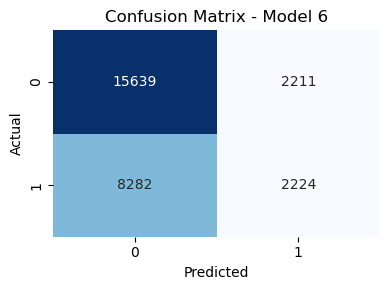

Optimization terminated successfully.
         Current function value: 0.654037
         Iterations 6


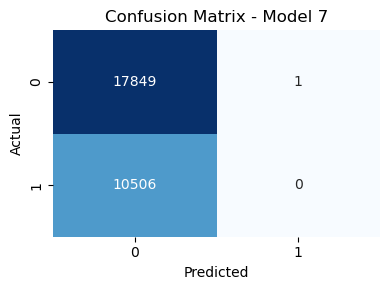

In [18]:
for i, formula in enumerate(formula_list):
    # Fit the model using statsmodels
    model = smf.logit(formula=formula, data=df).fit()

    # Predict probabilities
    pred_probs = model.predict(df)

    # Convert to class predictions (binary)
    y_pred = (pred_probs >= 0.5).astype(int)
    y_true = df['target']  

    # Confusion matrix
    cm = confusion_matrix(y_true, y_pred)

    # Plot confusion matrix
    plt.figure(figsize=(4, 3))
    sns.heatmap(cm, annot=True, fmt="d", cmap="Blues", cbar=False)
    plt.title(f"Confusion Matrix - Model {i}")
    plt.xlabel("Predicted")
    plt.ylabel("Actual")
    plt.tight_layout()
    plt.show()

Model 0, 1 and 7 has TP = 0 meaning that fails to capture the positive class. This is expected because of the inbalace on the data where not popular dominates the data.

Define a function that allows us to fit and calculates the training set performance for `formula_list`.


In [19]:
def fit_logistic_models (mod_name, formula, train_data, threshold):
    a_mod = smf.logit(formula=formula, data=train_data).fit()

    train_copy = train_data.copy()

    train_copy['pred_probability'] = a_mod.predict( train_data )

    train_copy['pred_class'] = np.where( train_copy.pred_probability > threshold, 1, 0 )
    
    significant_pvals = (a_mod.pvalues < 0.05).sum()
    
    TN, FP, FN, TP = confusion_matrix( train_copy.target.to_numpy(), train_copy.pred_class.to_numpy() ).ravel()

    Accuracy = ( TN + TP ) / ( TN + FP + FN + TP )

    Sensitivity = TP / (TP + FN)

    Specificity = TN / (TN + FP)

    FPR = 1 - Specificity

    ROC_AUC = roc_auc_score(train_copy.target.to_numpy(), train_copy.pred_class.to_numpy())

    res_dict = {'model_name': mod_name,
                'model_formula': formula,
                'num_coefs': len(a_mod.params),
                'num_significant_coefs': significant_pvals,
                'threshold': threshold,
                'Accuracy': Accuracy,
                'Sensitivity': Sensitivity, 
                'Specificity': Specificity,
                'FPR': FPR,
                'ROC_AUC': ROC_AUC}

    return pd.DataFrame( res_dict, index=[0] )
            

For-loop to iterate over all formulas.

In [20]:
results_list = []

for m in range(len(formula_list)):
    results_list.append( fit_logistic_models(m, formula_list[m], train_data=df, threshold=0.5))

Optimization terminated successfully.
         Current function value: 0.659223
         Iterations 4
Optimization terminated successfully.
         Current function value: 0.635450
         Iterations 5
Optimization terminated successfully.
         Current function value: 0.655644
         Iterations 4
Optimization terminated successfully.
         Current function value: 0.632931
         Iterations 5
Optimization terminated successfully.
         Current function value: 0.655419
         Iterations 5
Optimization terminated successfully.
         Current function value: 0.630261
         Iterations 6
Optimization terminated successfully.
         Current function value: 0.628309
         Iterations 6
Optimization terminated successfully.
         Current function value: 0.654037
         Iterations 6


Assign the results of the for-loop to `results_df`.

In [21]:
results_df = pd.concat( results_list, ignore_index=True )

Changing the number of the models to there actual name.

In [22]:
results_df['model_name'] = results_df['model_name'].replace({
    0: "model_intercept",
    1: "model_cat",
    2: "model_continuous",
    3: "model_all",
    4: "model_interactions",
    5: "model_interactions_cat_cont",
    6: "model_genre_year_interaction",
    7: "model_poly"
})

In [23]:
results_df

,model_name,model_formula,num_coefs,num_significant_coefs,threshold,Accuracy,Sensitivity,Specificity,FPR,ROC_AUC
0,model_intercept,target ~ 1,1,1,0.5,0.629496,0.000000,1.000000,0.000000,0.500000
1,model_cat,target ~ playlist_genre,6,6,0.5,0.629496,0.000000,1.000000,0.000000,0.500000
2,model_continuous,target ~ danceability + log_tempo + energy,4,4,0.5,0.629073,0.001713,0.998319,0.001681,0.500016
3,model_all,target ~ danceability + log_tempo + energy + p...,9,9,0.5,0.631224,0.108795,0.938711,0.061289,0.523753
4,model_interactions,target ~ danceability + log_tempo + energy + d...,7,5,0.5,0.628368,0.006377,0.994454,0.005546,0.500416
5,model_interactions_cat_cont,target ~ danceability + log_tempo + energy + p...,24,9,0.5,0.637854,0.172568,0.911709,0.088291,0.542138
6,model_genre_year_interaction,target ~ playlist_genre + bin_year + playlist_...,12,7,0.5,0.629955,0.211689,0.876134,0.123866,0.543912
7,model_poly,target ~ danceability + log_tempo + energy + I...,7,4,0.5,0.629461,0.000000,0.999944,0.000056,0.499972


The **model_interactions_cat_cont** performe the best Accuracy.

The **model_genre_year_interaction** peforme the best RUC_AUC score.

Both models outperforms the **model_intercept**.

The best module looking at the Accuracy is **model_interactions_cat_cont** which has 24 coeficients.

Let's create a function that returns ROC curve for each model.

In [24]:
def fit_logistic_make_roc(mod_name, formula, train_data):
    a_mod = smf.logit(formula=formula, data=train_data).fit()

    train_copy = train_data.copy()

    train_copy['pred_probability'] = a_mod.predict( train_data )

    fpr, tpr, threshold = roc_curve( train_data.target.to_numpy(), train_copy.pred_probability.to_numpy() )

    res_df = pd.DataFrame({'tpr': tpr,
                           'fpr': fpr,
                           'threshold': threshold})
    
    res_df['model_name'] = mod_name
    res_df['model_formula'] = formula

    return res_df

In [25]:
roc_list = []

for m in range( len(formula_list) ):
    roc_list.append( fit_logistic_make_roc( m, formula_list[m], train_data=df))

Optimization terminated successfully.
         Current function value: 0.659223
         Iterations 4
Optimization terminated successfully.
         Current function value: 0.635450
         Iterations 5
Optimization terminated successfully.
         Current function value: 0.655644
         Iterations 4
Optimization terminated successfully.
         Current function value: 0.632931
         Iterations 5
Optimization terminated successfully.
         Current function value: 0.655419
         Iterations 5
Optimization terminated successfully.
         Current function value: 0.630261
         Iterations 6
Optimization terminated successfully.
         Current function value: 0.628309
         Iterations 6
Optimization terminated successfully.
         Current function value: 0.654037
         Iterations 6


In [26]:
roc_df = pd.concat( roc_list, ignore_index=True )

In [27]:
roc_df['model_name'] = roc_df['model_name'].replace({
    0: "model_intercept",
    1: "model_cat",
    2: "model_continuous",
    3: "model_all",
    4: "model_interactions",
    5: "model_interactions_cat_cont",
    6: "model_genre_year_interaction",
    7: "model_poly"
})

In [28]:
roc_df

,tpr,fpr,threshold,model_name,model_formula
0,0.000000,0.000000,inf,model_intercept,target ~ 1
1,1.000000,1.000000,0.370504,model_intercept,target ~ 1
2,0.000000,0.000000,inf,model_cat,target ~ playlist_genre
3,0.241291,0.145490,0.493959,model_cat,target ~ playlist_genre
4,0.454026,0.322857,0.413812,model_cat,target ~ playlist_genre
...,...,...,...,...,...
65942,0.999810,0.999832,0.247756,model_poly,target ~ danceability + log_tempo + energy + I...
65943,0.999905,0.999832,0.247622,model_poly,target ~ danceability + log_tempo + energy + I...
65944,0.999905,0.999944,0.246142,model_poly,target ~ danceability + log_tempo + energy + I...
65945,1.000000,0.999944,0.245552,model_poly,target ~ danceability + log_tempo + energy + I...


Visualize the ROC curve of each model.

C:\Anaconda\envs\cmpinf2100\lib\site-packages\seaborn\axisgrid.py:123: UserWarning: The figure layout has changed to tight
  self._figure.tight_layout(*args, **kwargs)


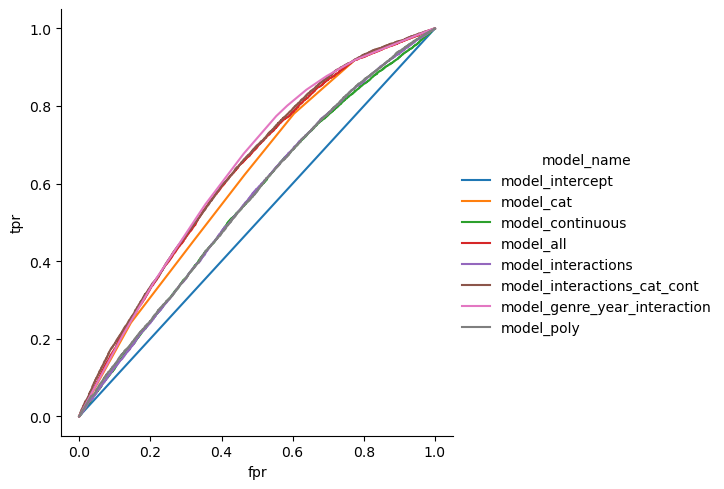

In [29]:
sns.relplot( data = roc_df, x='fpr', y='tpr', hue='model_name', 
            kind='line', estimator=None, units='model_name')

plt.show()

C:\Anaconda\envs\cmpinf2100\lib\site-packages\seaborn\axisgrid.py:123: UserWarning: The figure layout has changed to tight
  self._figure.tight_layout(*args, **kwargs)


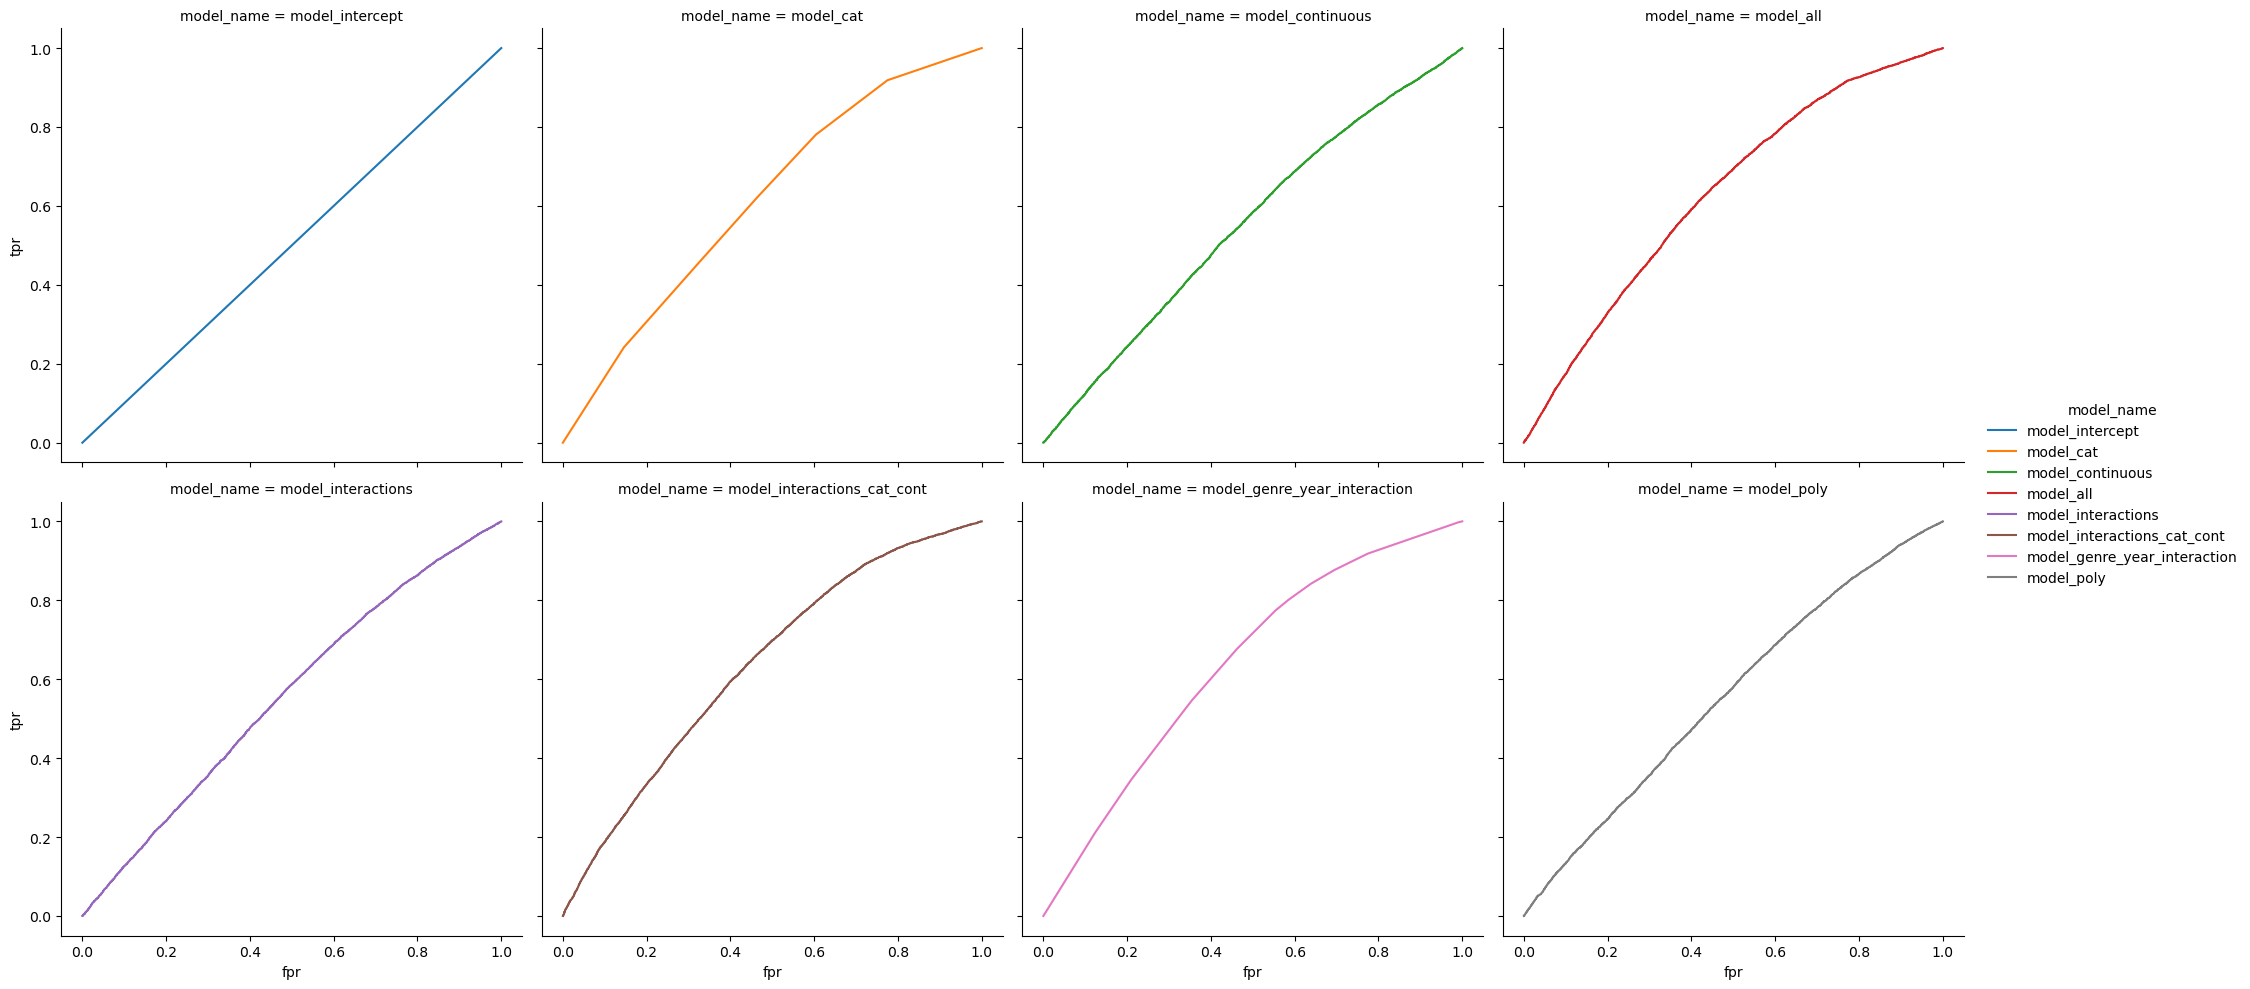

In [30]:
sns.relplot( data = roc_df, x='fpr', y='tpr', hue='model_name', 
            kind='line', estimator=None, units='model_name',
           col='model_name', col_wrap=4)

plt.show()

According to the training set the `model_interactions_cat_cont` has the most number of coefficients performce slightly better than the other models.

In [31]:
df.to_csv('df_model', index=False)